In [1]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from collections import Counter
from sklearn.preprocessing import StandardScaler
import torch

file = '/home/server/Projects/data/AKI/time_series_cleaned.csv'


# Initialize the dataset
df_aki = pd.read_csv("/home/server/Projects/data/AKI/preop_cleaned.csv")
df_aki['aki_boolean_float'] = df_aki['aki_boolean'].astype(float)

df = pd.read_csv(file)


df = df.fillna(0)
df = df.merge(df_aki[['op_id', 'aki']], on='op_id', how='inner')


tensors = {}
for op_id, group in tqdm(df.groupby("op_id"), desc="grouping by op_ids"):
    sequence_length = group.shape[0]
    mat = torch.tensor(group.drop(columns=['op_id', 'chart_time']).values)
    if sequence_length in tensors:
        tensors[sequence_length].append(mat)
    else:
        tensors[sequence_length] = [mat]
    if group.iloc[0]['aki'] > 0.3:
        tensors[sequence_length].extend([mat] * 9)


grouping by op_ids: 100%|██████████| 58587/58587 [00:24<00:00, 2357.92it/s]


In [2]:
data = torch.stack(tensors[28]).float()
X = data[:, :, :-1]
y = data[:, 0, -1].unsqueeze(1)


In [15]:
import torch
import torch.nn as nn
from torch.autograd import Variable
class LSTM1(nn.Module):
    def __init__(self, num_classes, input_size, hidden_size, num_layers, seq_length):
        super(LSTM1, self).__init__()
        self.num_classes = num_classes #number of classes
        self.num_layers = num_layers #number of layers
        self.input_size = input_size #input size
        self.hidden_size = hidden_size #hidden state
        self.seq_length = seq_length #sequence length

        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                          num_layers=num_layers, batch_first=True) #lstm
        self.fc_1 =  nn.Linear(hidden_size, 128) #fully connected 1
        self.fc = nn.Linear(128, num_classes) #fully connected last layer

        self.relu = nn.ReLU()
    
    def forward(self,x):
        h_0 = Variable(torch.zeros(self.num_layers, x.size(0), self.hidden_size)) #hidden state
        c_0 = Variable(torch.zeros(self.num_layers, x.size(0), self.hidden_size)) #internal state
        # Propagate input through LSTM
        output, (hn, cn) = self.lstm(x, (h_0, c_0)) #lstm with input, hidden, and internal state
        hn = hn.view(-1, self.hidden_size) #reshaping the data for Dense layer next
        out = self.relu(hn)
        out = self.fc_1(out) #first Dense
        out = self.relu(out) #relu
        out = self.fc(out) #Final Output
        return out

num_epochs = 10000 #1000 epochs
learning_rate = 0.001 #0.001 lr

input_size = 24 #number of features
hidden_size = 2 #number of features in hidden state
num_layers = 1 #number of stacked lstm layers

num_classes = 1 #number of output classes 

lstm1 = LSTM1(num_classes, input_size, hidden_size, num_layers, data.shape[1]) #our lstm class 

In [ ]:
criterion = torch.nn.MSELoss()    # mean-squared error for regression
optimizer = torch.optim.Adam(lstm1.parameters(), lr=learning_rate) 
for epoch in range(num_epochs):
  outputs = lstm1.forward(X) #forward pass
  # outputs = torch.clamp(lstm1.forward(X), min=0, max=1) #forward pass
  optimizer.zero_grad() #caluclate the gradient, manually setting to 0
 
  # obtain the loss function
  loss = criterion(outputs, y)
 
  loss.backward() #calculates the loss of the loss function
 
  optimizer.step() #improve from loss, i.e backprop
  if epoch % 500 == 0:
    print("Epoch: %d, loss: %1.5f" % (epoch, loss.item())) 

Epoch: 0, loss: 0.30326
Epoch: 500, loss: 0.28336
Epoch: 1000, loss: 0.28122
Epoch: 1500, loss: 0.28075
Epoch: 2000, loss: 0.28022
Epoch: 2500, loss: 0.28184
Epoch: 3000, loss: 0.28148
Epoch: 3500, loss: 0.27139
Epoch: 4000, loss: 0.27110


In [6]:
data_test = torch.stack(tensors[29]).float()
X_test = data[:, :, :-1]
y_test = data[:, 0, -1].unsqueeze(1)
outputs = lstm1(X_test)

In [7]:
sum((y_test > 0.3).T.tolist()[0])

620

In [8]:
y_test.T.tolist()[0]

[0.07000000029802322,
 -0.03999999910593033,
 0.07000000029802322,
 0.0,
 0.0,
 -0.029999999329447746,
 -0.03999999910593033,
 0.10999999940395355,
 0.5899999737739563,
 0.5899999737739563,
 0.5899999737739563,
 0.5899999737739563,
 0.5899999737739563,
 0.5899999737739563,
 0.5899999737739563,
 0.5899999737739563,
 0.5899999737739563,
 0.5899999737739563,
 0.20999999344348907,
 -0.4699999988079071,
 -0.23000000417232513,
 0.029999999329447746,
 -0.09000000357627869,
 0.10999999940395355,
 -0.07000000029802322,
 -0.1599999964237213,
 0.12999999523162842,
 -0.03999999910593033,
 -0.36000001430511475,
 0.25,
 0.18000000715255737,
 0.2800000011920929,
 -0.07000000029802322,
 0.11999999731779099,
 -0.07000000029802322,
 0.0,
 -0.09000000357627869,
 -0.029999999329447746,
 -0.05000000074505806,
 0.0,
 0.0,
 -0.03999999910593033,
 -0.05000000074505806,
 -0.10999999940395355,
 0.12999999523162842,
 0.05999999865889549,
 0.10999999940395355,
 0.05000000074505806,
 0.1599999964237213,
 -0.059999

In [32]:
outputs.T.tolist()[0]

[-0.0211649090051651,
 0.0003015473484992981,
 0.09017866849899292,
 -0.013224340975284576,
 -0.02625659853219986,
 0.08024292439222336,
 0.09017866849899292,
 -0.06877652555704117,
 0.08620254695415497,
 -0.051749199628829956,
 0.0013401880860328674,
 -0.05528531223535538,
 -0.01492106169462204,
 0.0788683146238327,
 0.09017866849899292,
 -0.016089849174022675,
 -0.022652097046375275,
 0.08587692677974701,
 0.09017866849899292,
 0.09017866849899292,
 0.05881872773170471,
 0.09017866849899292,
 0.03758900612592697,
 0.09017866849899292,
 0.061211518943309784,
 -0.06494570523500443,
 -0.019985683262348175,
 0.052705325186252594,
 -0.025823689997196198,
 0.09017866849899292,
 0.05867433547973633,
 0.047856979072093964,
 -0.00907987356185913,
 0.05326791852712631,
 -0.12446673959493637,
 0.09017866849899292,
 0.046883098781108856,
 0.09017866849899292,
 -0.055095501244068146,
 0.2663615643978119,
 0.09017866849899292,
 0.017471514642238617,
 0.016972456127405167,
 -0.11345545202493668,
 -

In [10]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve


In [12]:
print(classification_report((y_test > 0.3).T.tolist()[0], (outputs > 0.3).T.tolist()[0]))

              precision    recall  f1-score   support

       False       0.78      0.90      0.84      1240
        True       0.72      0.50      0.59       620

    accuracy                           0.77      1860
   macro avg       0.75      0.70      0.71      1860
weighted avg       0.76      0.77      0.75      1860



In [11]:
Counter(y_test.T.tolist()[0])

Counter({0.0: 1240, 1.0: 62})

In [23]:
Counter((outputs > 0.5).float().T.tolist()[0])

Counter({0.0: 1291, 1.0: 11})

In [9]:
def generate_data(seq_length, num_samples):
    X = []
    y = []
    for i in range(num_samples):
        x = np.linspace(i * 2 * np.pi, (i + 1) * 2 * np.pi, seq_length + 1)
        sine_wave = np.sin(x)
        X.append(sine_wave[:-1])  
        y.append(sine_wave[1:])   
    return np.array(X), np.array(y)

seq_length = 50
num_samples = 1000
X, y = generate_data(seq_length, num_samples)

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

In [11]:
X.shape

torch.Size([1000, 50])

In [12]:
y.shape

torch.Size([1000, 50])

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt

# Hyperparameters
input_size = 1
hidden_size = 16
output_size = 1
num_layers = 2
num_epochs = 100
seq_length = 10

# Generate toy data (e.g., a simple sine wave)
x = torch.linspace(0, 40, 400).reshape(-1, 1)
y = torch.sin(x)

# Prepare data for sequence learning
def create_sequences(data, seq_length):
    sequences = []
    labels = []
    for i in range(len(data) - seq_length):
        seq = data[i:i + seq_length]
        label = data[i + seq_length]
        sequences.append(seq)
        labels.append(label)
    return torch.stack(sequences), torch.stack(labels)

x_seq, y_seq = create_sequences(y, seq_length)
train_loader = DataLoader(TensorDataset(x_seq, y_seq), batch_size=16, shuffle=True)

In [6]:
print(x_seq.shape, y_seq.shape)

torch.Size([390, 10, 1]) torch.Size([390, 1])


In [13]:


# Define the RNN model
class SimpleRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers):
        super(SimpleRNN, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])  # Take the last time step
        return out

# Initialize the model
model = SimpleRNN(input_size, hidden_size, output_size, num_layers)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

# Training loop
for epoch in range(num_epochs):
    for seqs, labels in train_loader:
        outputs = model(seqs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')




Epoch [10/100], Loss: 0.0025
Epoch [20/100], Loss: 0.0003
Epoch [30/100], Loss: 0.0001
Epoch [40/100], Loss: 0.0001
Epoch [50/100], Loss: 0.0000
Epoch [60/100], Loss: 0.0000
Epoch [70/100], Loss: 0.0000
Epoch [80/100], Loss: 0.0001
Epoch [90/100], Loss: 0.0000
Epoch [100/100], Loss: 0.0001


In [15]:
# Test the model
model.eval()
test_input = x[-seq_length:].unsqueeze(0)
predictions = []

for _ in range(50):  # Generate 50 future time steps
    pred = model(test_input)
    predictions.append(pred.item())
    test_input = torch.cat((test_input[:, 1:, :], pred.unsqueeze(0)), dim=1)



In [16]:
test_input.shape

torch.Size([1, 50, 1])

In [20]:
predictions.shape

AttributeError: 'list' object has no attribute 'shape'

RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

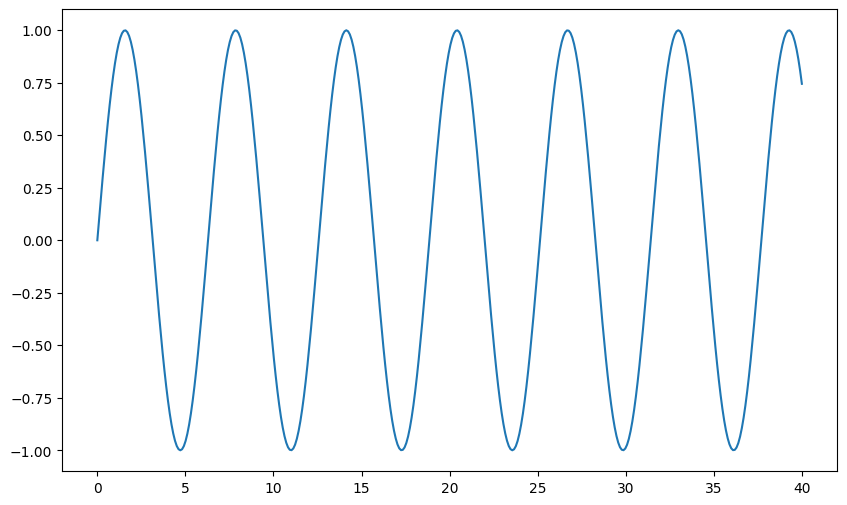

In [23]:
# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(x, y, label='Original Data')
plt.plot(test_input, predictions, label='Predicted Future', color='red')
plt.legend()
plt.show()

In [ ]:
# Test the model
model.eval()
test_input = y[-seq_length:].unsqueeze(0)
predictions = []

for _ in range(50):  # Generate 50 future time steps
    pred = model(test_input)
    predictions.append(pred.item())
    test_input = torch.cat((test_input[:, 1:, :], pred.unsqueeze(0)), dim=1)

# Plot the results
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(x, y, label='Original Data')
plt.plot(x[-50:], predictions, label='Predicted Future', color='red')
plt.legend()
plt.show()

In [11]:
def performance_dict(y_binary_test, y_pred, y_prob, bool_print=False, plot=False, copy_print=False):
    print("----------")
    rtn = {}
    report = classification_report(y_binary_test, y_pred, output_dict=True)
    rtn['Precision'] = report['True']['precision']
    rtn['Sensitivity'] = report['True']['recall']
    rtn["Accuracy"] = accuracy_score(y_binary_test, y_pred)
    fpr, tpr, thresholds = roc_curve(y_binary_test, y_prob)
    rtn["rc_auc"] = auc(fpr, tpr)
    prec, rec, thresholds = precision_recall_curve(y_binary_test, y_prob)
    rtn["pr_auc"] = auc(rec, prec)
    rtn['Specificity'] = report['False']['recall']
    rtn['Negative Predictive Value'] = report['False']['precision']
    rtn['F1 Score'] = report['True']['f1-score']

    if bool_print:
        for key, value in rtn.items():
            print(f"{key}: {value:.4f}")
    if copy_print:
        for item in rtn.items():
            print(f"{item[1]:.4f}")

    if plot:
        # Plot ROC Curve
        plt.figure()
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {rtn["rc_auc"]:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve (Using Regression Output)')
        plt.legend(loc='lower right')
        plt.show()

        # Plot PR curve
        plt.figure()
        plt.plot(prec, rec, color='yellow', lw=2, label=f'PR curve (area = {rtn["pr_auc"]:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('Precision')
        plt.ylabel('Recall')
        plt.title('Precision-Recall Curve')
        plt.legend(loc='lower right')
        plt.show()
        print("----------")

    return rtn
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve, average_precision_score
from joblib import Parallel, delayed

import numpy as np
from sklearn.svm import SVC
from tqdm import tqdm

file = "/home/server/Projects/data/AKI/tabular_combined.npz"

# Load data
with np.load(file, allow_pickle=True) as data:
    X_train = data["X_train"]
    X_test = data["X_test"]
    y_binary_train = data["y_binary_train"]
    y_binary_test = data["y_binary_test"]



In [3]:
batch_size = 2000
num_batches = int(np.ceil(len(X_train) / batch_size))
y_pred_sum = np.zeros(y_binary_test.shape)
y_prob_sum = np.zeros(y_binary_test.shape)

for i in tqdm(range(num_batches)):
    
    X_batch = X_train[i * batch_size : (i + 1) * batch_size]
    y_batch = y_binary_train[i * batch_size : (i + 1) * batch_size]
    svc = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
    svc.fit(X_batch, y_batch)

    y_pred_sum = y_pred_sum + svc.predict(X_test)
    y_prob_sum = y_prob_sum + svc.predict_proba(X_test)[:, 1]

  0%|          | 0/45 [00:00<?, ?it/s]

100%|██████████| 45/45 [15:13<00:00, 20.30s/it]


In [4]:
y_pred_sum

array([ 0.,  0.,  5., ...,  0.,  2., 15.])

In [17]:
((y_pred_sum / num_batches) > 0.5)[:10]

array([False, False, False,  True, False, False,  True,  True, False,
       False])

In [18]:
y_pred = (y_pred_sum / num_batches) > 0.5
y_prob = y_pred_sum / num_batches
performance_dict(y_binary_test, y_pred, y_prob, bool_print=True, plot=False, copy_print=True)

----------
Precision: 0.1799
Sensitivity: 0.7650
Accuracy: 0.7783
rc_auc: 0.8451
pr_auc: 0.4027
Specificity: 0.7791
Negative Predictive Value: 0.9813
F1 Score: 0.2913
0.1799
0.7650
0.7783
0.8451
0.4027
0.7791
0.9813
0.2913


{'Precision': 0.17991913746630728,
 'Sensitivity': 0.7650429799426934,
 'Accuracy': 0.778289810547875,
 'rc_auc': 0.8450898730622625,
 'pr_auc': 0.402729707662262,
 'Specificity': 0.7791288566243194,
 'Negative Predictive Value': 0.9812571428571428,
 'F1 Score': 0.29132569558101473}

In [10]:
y_pred = (y_prob_sum / num_batches) > 0.5
y_prob = y_prob_sum / num_batches
performance_dict(y_binary_test, y_pred, y_prob, bool_print=True, plot=False, copy_print=True)

----------
Precision: 0.1756
Sensitivity: 0.7708
Accuracy: 0.7708
rc_auc: 0.8514
pr_auc: 0.2678
Specificity: 0.7708
Negative Predictive Value: 0.9815
F1 Score: 0.2860
0.1756
0.7708
0.7708
0.8514
0.2678
0.7708
0.9815
0.2860


{'Precision': 0.17558746736292427,
 'Sensitivity': 0.7707736389684814,
 'Accuracy': 0.7707799965864482,
 'rc_auc': 0.8513767622296529,
 'pr_auc': 0.2677814487001988,
 'Specificity': 0.7707803992740472,
 'Negative Predictive Value': 0.9815114397966258,
 'F1 Score': 0.2860180754917597}

In [39]:
y_binary_test.shape

(11718,)

In [37]:
y_pred.shape

(11718,)

In [26]:
(y_prob + y_prob) / 2

array([0.20107036, 0.13549884, 0.44091971, ..., 0.09718655, 0.16044904,
       0.36368808])

In [ ]:
# -------------------- SUPPORT VECTOR CLASSIFICATION (SVC) --------------------
print("\nSVM Classification:")

# Train SVM classifier (RBF kernel works best for most cases)
svc = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
svc.fit(X_train, y_binary_train)

# Predict binary labels
y_pred = svc.predict(X_test)

y_prob = svc.predict_proba(X_test)[:, 1]

performance_dict(y_binary_test, y_pred, y_prob, bool_print=True, plot=False, copy_print=True)

In [2]:
svm_0 = SVC(kernel='rbf', probability=True, random_state=42)
svm_1 = SVC(kernel='rbf', probability=True, random_state=42)
svm_2 = SVC(kernel='rbf', probability=True, random_state=42)
svm_3 = SVC(kernel='rbf', probability=True, random_state=42)
svm_4 = SVC(kernel='rbf', probability=True, random_state=42)
svm_5 = SVC(kernel='rbf', probability=True, random_state=42)
svm_6 = SVC(kernel='rbf', probability=True, random_state=42)
svm_7 = SVC(kernel='rbf', probability=True, random_state=42)
svm_8 = SVC(kernel='rbf', probability=True, random_state=42)
svm_9 = SVC(kernel='rbf', probability=True, random_state=42)


# Voting Classifier (Soft Voting: Uses Predicted Probabilities)
ensemble = VotingClassifier(
    estimators=[
        ('svm_0', svm_0),
        ('svm_1', svm_1),
        ('svm_2', svm_2),
        ('svm_3', svm_3),
        ('svm_4', svm_4),
        ('svm_5', svm_5),
        ('svm_6', svm_6),
        ('svm_7', svm_7),
        ('svm_8', svm_8),
        ('svm_9', svm_9),
    ],
    voting='soft'  # Uses probability-based voting
)



In [ ]:

# Train Ensemble Model
ensemble.fit(X_train, y_binary_train)

In [ ]:


# Predict binary labels
y_pred = ensemble.predict(X_test)


# Predict probabilities for ROC curve
y_prob = ensemble.predict_proba(X_test)[:, 1]

NameError: name 'y_prob_sum' is not defined

In [17]:
with np.load(file, allow_pickle=True) as data:
    X_train=data["X_train"]
    X_test=data["X_test"]
    y_train=data["y_train"]
    y_test=data["y_test"]
    y_binary_train=data["y_binary_train"]
    y_binary_test=data["y_binary_test"]

architectures = [   (8, 8, 4, 32, 2),
                    (8, 16, 4, 16, 2),
                    (32, 16, 32, 2),
                    (64, 16, 16, 8)
                    ]
before = time.time()
for arch in architectures:
    print(arch)
    model = MLPClassifier(random_state=42, max_iter=1000, hidden_layer_sizes=arch)
    model.fit(X_train, y_binary_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    print(arch)
    performance_dict(y_binary_test, y_pred, y_prob, bool_print=True, plot=False, copy_print=True)
elapsed_time = time.time() - before
print(elapsed_time)

(8, 8, 4, 32, 2)
(8, 8, 4, 32, 2)
----------
Precision: 0.1982
Sensitivity: 0.4771
Accuracy: 0.8539
rc_auc: 0.6927
pr_auc: 0.1913
Specificity: 0.8778
Negative Predictive Value: 0.9636
F1 Score: 0.2801
0.1982
0.4771
0.8539
0.6927
0.1913
0.8778
0.9636
0.2801
(8, 16, 4, 16, 2)
(8, 16, 4, 16, 2)
----------
Precision: 0.1260
Sensitivity: 0.6533
Accuracy: 0.7094
rc_auc: 0.7071
pr_auc: 0.3920
Specificity: 0.7130
Negative Predictive Value: 0.9701
F1 Score: 0.2113
0.1260
0.6533
0.7094
0.7071
0.3920
0.7130
0.9701
0.2113
(32, 16, 32, 2)
(32, 16, 32, 2)
----------
Precision: 0.1770
Sensitivity: 0.3410
Accuracy: 0.8663
rc_auc: 0.7071
pr_auc: 0.2586
Specificity: 0.8995
Negative Predictive Value: 0.9557
F1 Score: 0.2330
0.1770
0.3410
0.8663
0.7071
0.2586
0.8995
0.9557
0.2330
(64, 16, 16, 8)
(64, 16, 16, 8)
----------
Precision: 0.2094
Sensitivity: 0.2693
Accuracy: 0.8959
rc_auc: 0.6993
pr_auc: 0.1562
Specificity: 0.9356
Negative Predictive Value: 0.9529
F1 Score: 0.2356
0.2094
0.2693
0.8959
0.6993
0.

In [ ]:
import numpy as np
from sklearn.svm import SVC, LinearSVC

file = "/home/server/Projects/data/AKI/tabular_combined.npz"

endpoint = 515
samp = 5000

# Load data
with np.load(file, allow_pickle=True) as data:
    X_train = data["X_train"]
    X_test = data["X_test"]
    y_binary_train = data["y_binary_train"]
    y_binary_test = data["y_binary_test"][:samp]


In [13]:
# -------------------- SUPPORT VECTOR CLASSIFICATION (SVC) --------------------
print("\nSVM Classification:")

# Train SVM classifier (RBF kernel works best for most cases)
svc = SVC(kernel='rbf', probability=True, random_state=42)
svc.fit(X_train, y_binary_train)

# Predict binary labels
y_pred = svc.predict(X_test)

y_prob = svc.predict_proba(X_test)[:, 1]

performance_dict(y_binary_test, y_pred, y_prob, bool_print=True, plot=False, copy_print=True)


SVM Classification:
----------
Precision: 0.1887
Sensitivity: 0.7394
Accuracy: 0.8046
rc_auc: 0.8478
pr_auc: 0.2668
Specificity: 0.8085
Negative Predictive Value: 0.9810
F1 Score: 0.3006
0.1887
0.7394
0.8046
0.8478
0.2668
0.8085
0.9810
0.3006


{'Precision': 0.18867924528301888,
 'Sensitivity': 0.7394366197183099,
 'Accuracy': 0.8046,
 'rc_auc': 0.8478482749764062,
 'pr_auc': 0.26682493181206823,
 'Specificity': 0.8085241730279898,
 'Negative Predictive Value': 0.980962181631078,
 'F1 Score': 0.3006442376521117}

In [20]:
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

inspire_path = Path("/home/server/Projects/data/INSPIRE/physionet.org/files/inspire/1.3")
vitals_file = inspire_path / "vitals.csv"
preop_cleaned = "/home/server/Projects/data/AKI/preop_cleaned.csv"
output_csv = '/home/server/Projects/data/AKI/time_series_cleaned.csv'

In [2]:
file = "/home/server/Projects/data/AKI/tabular_combined.npz"

with np.load(file, allow_pickle=True) as data:
    X_train = data["X_train"]
    X_test = data["X_test"]
    y_binary_train = data["y_binary_train"]
    y_binary_test = data["y_binary_test"]

In [5]:
X_train.shape

(88160, 515)

In [6]:
X_test.shape

(11718, 515)

In [3]:
df = pd.DataFrame(np.vstack((X_test, X_train)))

In [4]:
column_variances = df.var()


In [10]:

print(column_variances.sort_values()[:20])

248        0.0
15         0.0
251        0.0
266        0.0
27     0.00001
26     0.00002
18     0.00004
29     0.00004
368    0.00023
488    0.00023
392    0.00023
320    0.00023
344    0.00023
464    0.00023
24     0.00047
307    0.00051
355    0.00051
379    0.00051
475    0.00051
451    0.00051
dtype: object


In [14]:
df.iloc[:,:270]

,0,1,2,3,4,5,6,7,8,9,...,260,261,262,263,264,265,266,267,268,269
0,-0.562517,True,0.853081,-0.251433,2.0,0.0,0.023223,-0.845158,-0.60024,0.0,...,0.070798,1.52204,0.095658,0.049682,0.07124,0.120136,-0.0,0.095304,-0.486797,-0.484914
1,-0.892939,True,0.298345,0.175574,1.0,0.0,0.252522,-0.000027,-0.679693,0.0,...,0.070798,0.043833,0.095658,0.049682,0.07124,0.120136,-0.0,0.095304,0.024309,-0.724186
2,-1.223362,False,-0.811126,0.602581,1.0,0.0,0.306284,1.427907,2.220359,0.0,...,0.070798,-0.232027,0.095658,0.049682,0.07124,0.120136,-0.0,0.095304,-0.58211,0.006266
3,-1.223362,False,-0.811126,-1.105448,2.0,0.0,-1.134736,-0.831476,1.465551,0.0,...,0.070798,-0.447245,0.095658,-2.236735,0.07124,0.120136,-0.0,0.095304,0.122042,-0.175545
4,-1.884207,False,-0.256391,-1.959462,2.0,1.0,-1.852518,-2.239178,-0.123519,1.0,...,0.070798,0.043833,0.095658,-1.573433,0.07124,0.120136,-0.0,0.095304,0.744956,-1.316241
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99873,0.098328,True,0.298345,-1.105448,2.0,0.0,-0.884987,-1.49539,-0.441333,0.0,...,0.070798,-0.136136,0.095658,0.089107,0.07124,0.120136,-0.0,0.095304,0.024309,-0.761786
99874,-0.562517,False,-1.365862,0.602581,2.0,0.0,0.154954,1.963883,1.783365,0.0,...,0.070798,-0.462006,0.095658,0.049682,0.07124,0.120136,-0.0,-1.890545,-0.610645,0.622979
99875,-0.892939,True,0.853081,1.456595,2.0,0.0,1.419102,1.033101,-0.004338,0.0,...,0.070798,-1.006172,0.095658,0.049682,0.07124,0.120136,-0.0,0.095304,-1.051673,-1.118985
99876,1.089596,True,0.853081,1.029588,2.0,0.0,1.088256,0.563537,0.035388,1.0,...,0.070798,0.043833,0.095658,0.049682,0.07124,0.120136,-0.0,0.095304,-0.721019,-0.666611


In [23]:
pca = PCA()
pca.fit(df)

PCA()

In [24]:
tot = 0
sofar = []
for decimal in pca.explained_variance_ratio_:
    tot += decimal
    sofar.append(tot)

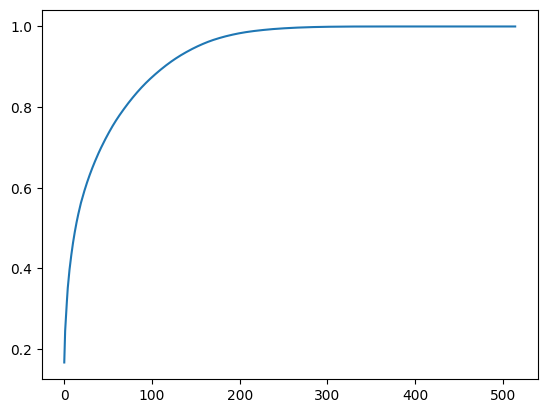

In [25]:
plt.plot(sofar)

In [93]:
def filter_df(df, item_name=0, op_id=0):
    rtn = df.copy()
    if item_name:
        rtn = rtn.loc[rtn['item_name'] == item_name]
    if op_id:
        rtn = rtn.loc[rtn['op_id'] == op_id]
    return rtn

def format_string(input_string):
    words = input_string.split()
    formatted = ', '.join(f'"{word}"' for word in words)
    return formatted

In [ ]:
# set up time series data loader to filter to the ones we want for high and medium frequency

In [42]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.stats import entropy, kurtosis, skew

inspire_path = Path("/home/server/Projects/data/INSPIRE/physionet.org/files/inspire/1.3")
vitals_file = inspire_path / "vitals.csv"
preop_cleaned = "/home/server/Projects/data/AKI/preop_cleaned.csv"
output_file = '/home/server/Projects/data/AKI/feature_engineered.csv'


# Load data from CSVs
print(f"Loading Data")
df_vitals = pd.read_csv(vitals_file)
df_preop = pd.read_csv(preop_cleaned)

# Cut down df_vitals to only include op_ids included in df_preop
df_vitals = df_vitals[df_vitals['op_id'].isin(df_preop['op_id'].unique())]

Loading Data
